In [1]:
# Cellule 1 — Config & Imports

In [5]:
# ══════════════════════════════════════════════════════════════
#  NOTEBOOK 02 — PREPROCESSING
#  Un seul paramètre à changer entre les bases
# ══════════════════════════════════════════════════════════════

# ── Seul paramètre à modifier ─────────────────────────────────
BASE_NAME        = "STE_NGDM"
MIN_JOURS_SORTIE = 30          # seuil minimum pour Prophet
GAP_JOURS        = 30          # gap pour détecter date isolée

# ── Manipulation données ──────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Connexion SQL Server ──────────────────────────────────────
import pyodbc

# ── ML ────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

# ── Utilitaires ───────────────────────────────────────────────
import warnings
import os
warnings.filterwarnings('ignore')

# ── Style graphes ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi']     = 120

# ── Dossiers de sortie ────────────────────────────────────────
OUTPUT_DIR    = f"../../output/{BASE_NAME}/data_clean/"
EXPLORE_DIR   = f"../../output/{BASE_NAME}/exploration/"
os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(EXPLORE_DIR, exist_ok=True)

print("✅ Imports OK")
print(f"📦 Base ciblée  : {BASE_NAME}")
print(f"📁 Output clean : {OUTPUT_DIR}")

✅ Imports OK
📦 Base ciblée  : STE_NGDM
📁 Output clean : ../../output/STE_NGDM/data_clean/


In [ ]:
# Cellule 2 — Connexion + Chargement

In [6]:
# ── Connexion SQL Server ──────────────────────────────────────
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=SALMAIKSOD\SAGE100;"
    "DATABASE=Test;"
    "UID=sa;PWD=123456;"
)

print(f"✅ Connecté à SQL Server")
print(f"📦 Base ciblée : {BASE_NAME}")

✅ Connecté à SQL Server
📦 Base ciblée : STE_NGDM


In [7]:
# ── Chargement mouvements ─────────────────────────────────────
query_mvt = f"""
SELECT
    DateJour, AR_Ref, AR_Design,
    FA_CodeFamille, FA_Intitule,
    CL_No1, CL_Intitule1,
    CL_No2, CL_Intitule2,
    CL_No3, CL_Intitule3,
    CL_No4, CL_Intitule4,
    DE_No, DE_Intitule,
    TotalEntree, TotalSortie,
    ValeurEntree, ValeurSortie,
    TotalValeurMouvement
FROM Test.stock.VW_MouvementsJournaliers
WHERE BaseName = '{BASE_NAME}'
ORDER BY DateJour, AR_Ref, DE_No
"""

df_mvt = pd.read_sql(query_mvt, conn)
df_mvt['DateJour'] = pd.to_datetime(df_mvt['DateJour'])

print(f" Mouvements chargés    : {len(df_mvt):,} lignes")
print(f"📅 Période brute         : {df_mvt['DateJour'].min().date()} → {df_mvt['DateJour'].max().date()}")
print(f"   Articles              : {df_mvt['AR_Ref'].nunique()}")
print(f"   Dépôts                : {df_mvt['DE_No'].nunique()}")

 Mouvements chargés    : 16,972 lignes
📅 Période brute         : 2022-12-31 → 2025-10-01
   Articles              : 278
   Dépôts                : 12


In [9]:
# ── Chargement stock journalier ───────────────────────────────
query_stock = f"""
SELECT
    DateJour, AR_Ref, AR_Design,
    FA_CodeFamille, FA_Intitule,
    CL_No1, CL_Intitule1,
    DE_No, DE_Intitule,
    TotalEntree, TotalSortie,
    ValeurEntree, ValeurSortie,
    StockInitial, StockFinal,
    ValeurInitiale, ValeurFinale
FROM Test.stock.StockJournalierCache
WHERE BaseName = '{BASE_NAME}'
ORDER BY DateJour, AR_Ref, DE_No
"""

df_stock = pd.read_sql(query_stock, conn)
df_stock['DateJour'] = pd.to_datetime(df_stock['DateJour'])

print(f" Stock journalier chargé : {len(df_stock):,} lignes")

 Stock journalier chargé : 16,972 lignes


In [10]:
# Cellule 3 — Nettoyer les dates aberrantes

In [11]:
# ── Sauvegarder la période originale pour le résumé final ─────
date_debut_originale = df_mvt['DateJour'].min().date()
date_fin_originale   = df_mvt['DateJour'].max().date()
nb_articles_initial  = df_mvt['AR_Ref'].nunique()

# ── Détecter les dates isolées (début, milieu, fin) ───────────
dates  = pd.Series(df_mvt['DateJour'].sort_values().unique())

gaps_avant = dates.diff()
gaps_apres = dates.diff(-1).abs()

# Date isolée au milieu : grand trou avant ET après
isolees_milieu = dates[
    (gaps_avant > pd.Timedelta(days=GAP_JOURS)) &
    (gaps_apres > pd.Timedelta(days=GAP_JOURS))
]

# Première date isolée : seulement grand trou après
isolee_debut = pd.Series(dtype='datetime64[ns]')
if gaps_apres.iloc[0] > pd.Timedelta(days=GAP_JOURS):
    isolee_debut = dates.iloc[[0]]

# Dernière date isolée : seulement grand trou avant
isolee_fin = pd.Series(dtype='datetime64[ns]')
if gaps_avant.iloc[-1] > pd.Timedelta(days=GAP_JOURS):
    isolee_fin = dates.iloc[[-1]]

# Toutes les dates aberrantes
dates_aberrantes = pd.concat([
    isolee_debut,
    isolees_milieu,
    isolee_fin
]).unique()

# ── Supprimer les dates aberrantes ────────────────────────────
if len(dates_aberrantes) > 0:
    df_mvt   = df_mvt[~df_mvt['DateJour'].isin(dates_aberrantes)]
    df_stock = df_stock[~df_stock['DateJour'].isin(dates_aberrantes)]
    print(f"⚠️  Dates aberrantes supprimées : {len(dates_aberrantes)}")
    for d in sorted(dates_aberrantes):
        print(f"   → {pd.Timestamp(d).date()}")
else:
    print("Aucune date aberrante détectée")

print(f"📅 Période après nettoyage : {df_mvt['DateJour'].min().date()} → {df_mvt['DateJour'].max().date()}")

⚠️  Dates aberrantes supprimées : 3
   → 2025-02-05
   → 2025-05-23
   → 2025-10-01
📅 Période après nettoyage : 2022-12-31 → 2025-08-27


In [12]:
# Cellule 4 — Traiter les valeurs manquantes

In [14]:
# ── Détecter dynamiquement toutes les colonnes avec NaN ───────
cols_nan_mvt   = df_mvt.columns[df_mvt.isnull().any()].tolist()
cols_nan_stock = df_stock.columns[df_stock.isnull().any()].tolist()

print(f"Colonnes avec NaN dans df_mvt   : {len(cols_nan_mvt)}")
for col in cols_nan_mvt:
    nb  = df_mvt[col].isnull().sum()
    pct = nb / len(df_mvt) * 100
    print(f"   {col:25s} → {nb:,} NaN ({pct:.1f}%)")

print(f"\nColonnes avec NaN dans df_stock : {len(cols_nan_stock)}")
for col in cols_nan_stock:
    nb  = df_stock[col].isnull().sum()
    pct = nb / len(df_stock) * 100
    print(f"   {col:25s} → {nb:,} NaN ({pct:.1f}%)")

# ── Traitement df_mvt ─────────────────────────────────────────
for col in cols_nan_mvt:
    if df_mvt[col].dtype == object:
        df_mvt[col] = df_mvt[col].fillna("INCONNU")
    else:
        df_mvt[col] = df_mvt[col].fillna(0)

# ── Traitement df_stock ───────────────────────────────────────
for col in cols_nan_stock:
    if df_stock[col].dtype == object:
        df_stock[col] = df_stock[col].fillna("INCONNU")
    else:
        df_stock[col] = df_stock[col].fillna(0)

# ── Vérification ──────────────────────────────────────────────
nan_mvt   = df_mvt.isnull().sum().sum()
nan_stock = df_stock.isnull().sum().sum()
print(f"\n✅ NaN restants df_mvt   : {nan_mvt}")
print(f"✅ NaN restants df_stock : {nan_stock}")

Colonnes avec NaN dans df_mvt   : 1
   CL_Intitule4              → 16,937 NaN (100.0%)

Colonnes avec NaN dans df_stock : 0

✅ NaN restants df_mvt   : 0
✅ NaN restants df_stock : 0


In [ ]:
# Cellule 5 — Calendrier complet

In [16]:
# ── Calendrier complet de la période ─────────────────────────
date_debut = df_mvt['DateJour'].min()
date_fin   = df_mvt['DateJour'].max()

articles = df_stock['AR_Ref'].unique()
depots   = df_stock['DE_No'].unique()

print(f"📅 Période     : {date_debut.date()} → {date_fin.date()}")
print(f"   Articles    : {len(articles)}")
print(f"   Dépôts      : {len(depots)}")

# ── Construire index complet article × dépôt × jour ──────────
index_complet = pd.MultiIndex.from_product(
    [pd.date_range(date_debut, date_fin), articles, depots],
    names=['DateJour', 'AR_Ref', 'DE_No']
)

df_calendar = pd.DataFrame(index=index_complet).reset_index()

# ── Merger avec le stock réel ─────────────────────────────────
df_full = df_calendar.merge(
    df_stock,
    on=['DateJour', 'AR_Ref', 'DE_No'],
    how='left'
)

nb_jours_total    = df_full['DateJour'].nunique()
nb_jours_avec_mvt = df_stock['DateJour'].nunique()
nb_jours_remplis  = nb_jours_total - nb_jours_avec_mvt

print(f"\n - Calendrier construit")
print(f"   Jours total          : {nb_jours_total}")
print(f"   Jours avec mouvement : {nb_jours_avec_mvt}")
print(f"   Jours à remplir      : {nb_jours_remplis}")
print(f"   Lignes df_full       : {len(df_full):,}")

📅 Période     : 2022-12-31 → 2025-08-27
   Articles    : 276
   Dépôts      : 12

 - Calendrier construit
   Jours total          : 971
   Jours avec mouvement : 583
   Jours à remplir      : 388
   Lignes df_full       : 3,215,952


In [17]:
# Cellule 6 — Remplir les jours sans mouvement

In [18]:
df_full = df_full.sort_values(['AR_Ref', 'DE_No', 'DateJour'])

# ── TotalSortie et TotalEntree → 0 si pas de mouvement ────────
df_full['TotalSortie']  = df_full['TotalSortie'].fillna(0)
df_full['TotalEntree']  = df_full['TotalEntree'].fillna(0)
df_full['ValeurSortie'] = df_full['ValeurSortie'].fillna(0)
df_full['ValeurEntree'] = df_full['ValeurEntree'].fillna(0)

# ── StockFinal → reporter la dernière valeur connue ───────────
df_full['StockFinal'] = df_full.groupby(['AR_Ref', 'DE_No'])['StockFinal'] \
                                .transform(lambda x: x.ffill())

# ── Colonnes texte → propager la valeur connue ────────────────
cols_texte = ['AR_Design', 'FA_CodeFamille', 'FA_Intitule',
              'DE_Intitule', 'CL_No1', 'CL_Intitule1',
              'CL_No2', 'CL_Intitule2']

for col in cols_texte:
    if col in df_full.columns:
        df_full[col] = df_full.groupby(['AR_Ref', 'DE_No'])[col] \
                               .transform(lambda x: x.ffill().bfill())

# ── Vérification ──────────────────────────────────────────────
nan_stock = df_full['StockFinal'].isnull().sum()
print(f"✅ Jours remplis")
print(f"   NaN restants StockFinal : {nan_stock}")
print(f"   (NaN = articles sans aucun stock historique)")

✅ Jours remplis
   NaN restants StockFinal : 2948222
   (NaN = articles sans aucun stock historique)


In [20]:
# Cellule 7 — Agréger par article (supprimer dépôts)

In [21]:
# ── Agréger tous les dépôts par article ──────────────────────
# Prophet, RF, K-Means travaillent sur l'article total
# pas article × dépôt

df_total = df_full.groupby(['DateJour', 'AR_Ref']).agg(
    AR_Design      = ('AR_Design',      'first'),
    FA_CodeFamille = ('FA_CodeFamille', 'first'),
    FA_Intitule    = ('FA_Intitule',    'first'),
    TotalSortie    = ('TotalSortie',    'sum'),
    TotalEntree    = ('TotalEntree',    'sum'),
    ValeurSortie   = ('ValeurSortie',   'sum'),
    ValeurEntree   = ('ValeurEntree',   'sum'),
    StockFinal     = ('StockFinal',     'sum')
).reset_index()

df_total = df_total.sort_values(['AR_Ref', 'DateJour'])

print(f"✅ Agrégation par article")
print(f"   Lignes df_full  (avec dépôts) : {len(df_full):,}")
print(f"   Lignes df_total (sans dépôts) : {len(df_total):,}")
print(f"   Articles                      : {df_total['AR_Ref'].nunique()}")
print(f"   Jours                         : {df_total['DateJour'].nunique()}")

✅ Agrégation par article
   Lignes df_full  (avec dépôts) : 3,215,952
   Lignes df_total (sans dépôts) : 267,996
   Articles                      : 276
   Jours                         : 971


In [ ]:
# Cellule 7b — Graphe calendrier complet 

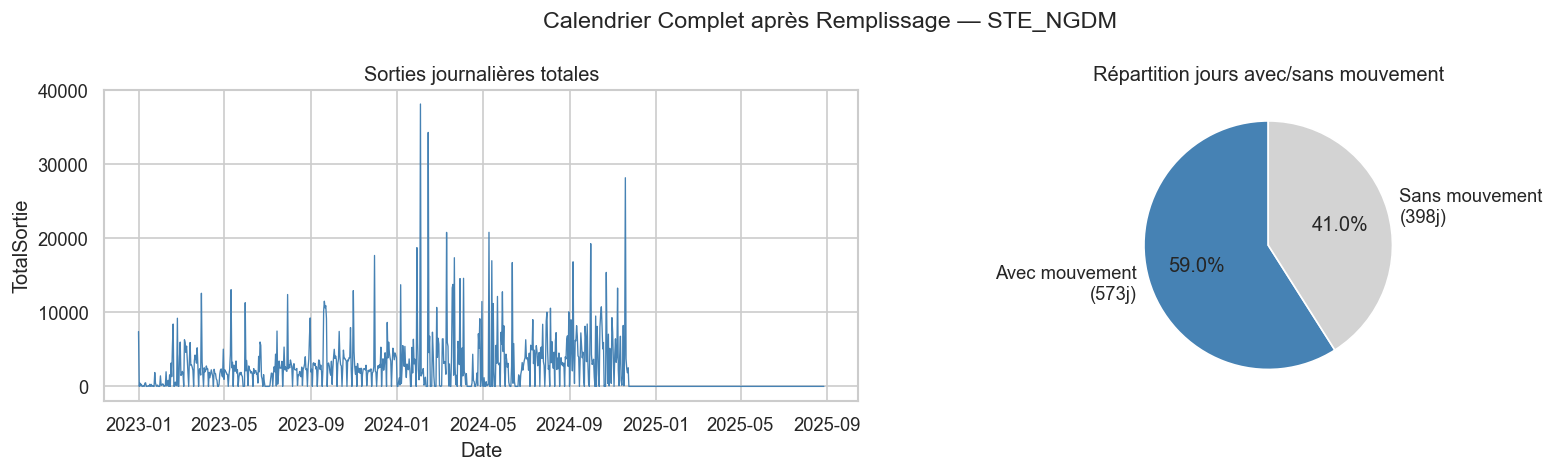

 Graphe sauvegardé : calendrier_complet.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'Calendrier Complet après Remplissage — {BASE_NAME}', fontsize=14)

# ── Évolution TotalSortie global ──────────────────────────────
daily = df_total.groupby('DateJour')['TotalSortie'].sum()
axes[0].plot(daily.index, daily.values, color='steelblue', linewidth=0.8)
axes[0].set_title('Sorties journalières totales')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('TotalSortie')

# ── Taux de jours avec mouvement ─────────────────────────────
jours_avec    = (daily > 0).sum()
jours_sans    = (daily == 0).sum()
axes[1].pie(
    [jours_avec, jours_sans],
    labels=[f'Avec mouvement\n({jours_avec}j)', f'Sans mouvement\n({jours_sans}j)'],
    colors=['steelblue', 'lightgray'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Répartition jours avec/sans mouvement')

plt.tight_layout()
plt.savefig(f"{EXPLORE_DIR}calendrier_complet.png", dpi=120, bbox_inches='tight')
plt.show()
print(" Graphe sauvegardé : calendrier_complet.png")

In [24]:
# Cellule 8 — Filtrer articles ≥ 30 jours de sortie

In [26]:
# ── Compter les jours avec sortie > 0 par article ────────────
jours_sortie = df_total[df_total['TotalSortie'] > 0] \
    .groupby('AR_Ref')['DateJour'].nunique() \
    .reset_index() \
    .rename(columns={'DateJour': 'NbJoursSortie'})

articles_valides = jours_sortie[
    jours_sortie['NbJoursSortie'] >= MIN_JOURS_SORTIE
]['AR_Ref'].tolist()

nb_exclus = df_total['AR_Ref'].nunique() - len(articles_valides)

df_total = df_total[df_total['AR_Ref'].isin(articles_valides)]

print(f"✅ Filtrage articles")
print(f"   Seuil                : ≥ {MIN_JOURS_SORTIE} jours de sortie")
print(f"   Articles retenus     : {len(articles_valides)}")
print(f"   Articles exclus      : {nb_exclus} (trop peu de données)")

✅ Filtrage articles
   Seuil                : ≥ 30 jours de sortie
   Articles retenus     : 132
   Articles exclus      : 144 (trop peu de données)


In [25]:
# Cellule 9 — Features temporelles

In [28]:
# ── Features calculées depuis DateJour ───────────────────────
# Identiques pour toutes les bases quelle que soit la période

df_total['jour_semaine'] = df_total['DateJour'].dt.dayofweek
df_total['mois']         = df_total['DateJour'].dt.month
df_total['trimestre']    = df_total['DateJour'].dt.quarter
df_total['annee']        = df_total['DateJour'].dt.year
df_total['is_weekend']   = df_total['jour_semaine'].isin([5, 6]).astype(int)

# is_fin_mois : dernier jour du mois
df_total['is_fin_mois'] = (
    df_total['DateJour'] + pd.Timedelta(days=1)
).dt.month != df_total['DateJour'].dt.month
df_total['is_fin_mois'] = df_total['is_fin_mois'].astype(int)

# is_debut_mois : premier jour du mois
df_total['is_debut_mois'] = (df_total['DateJour'].dt.day == 1).astype(int)

print("- Features temporelles créées")
print(f"   jour_semaine, mois, trimestre, annee")
print(f"   is_weekend, is_fin_mois, is_debut_mois")

- Features temporelles créées
   jour_semaine, mois, trimestre, annee
   is_weekend, is_fin_mois, is_debut_mois


In [27]:
# Cellule 9b — Graphe features temporelles

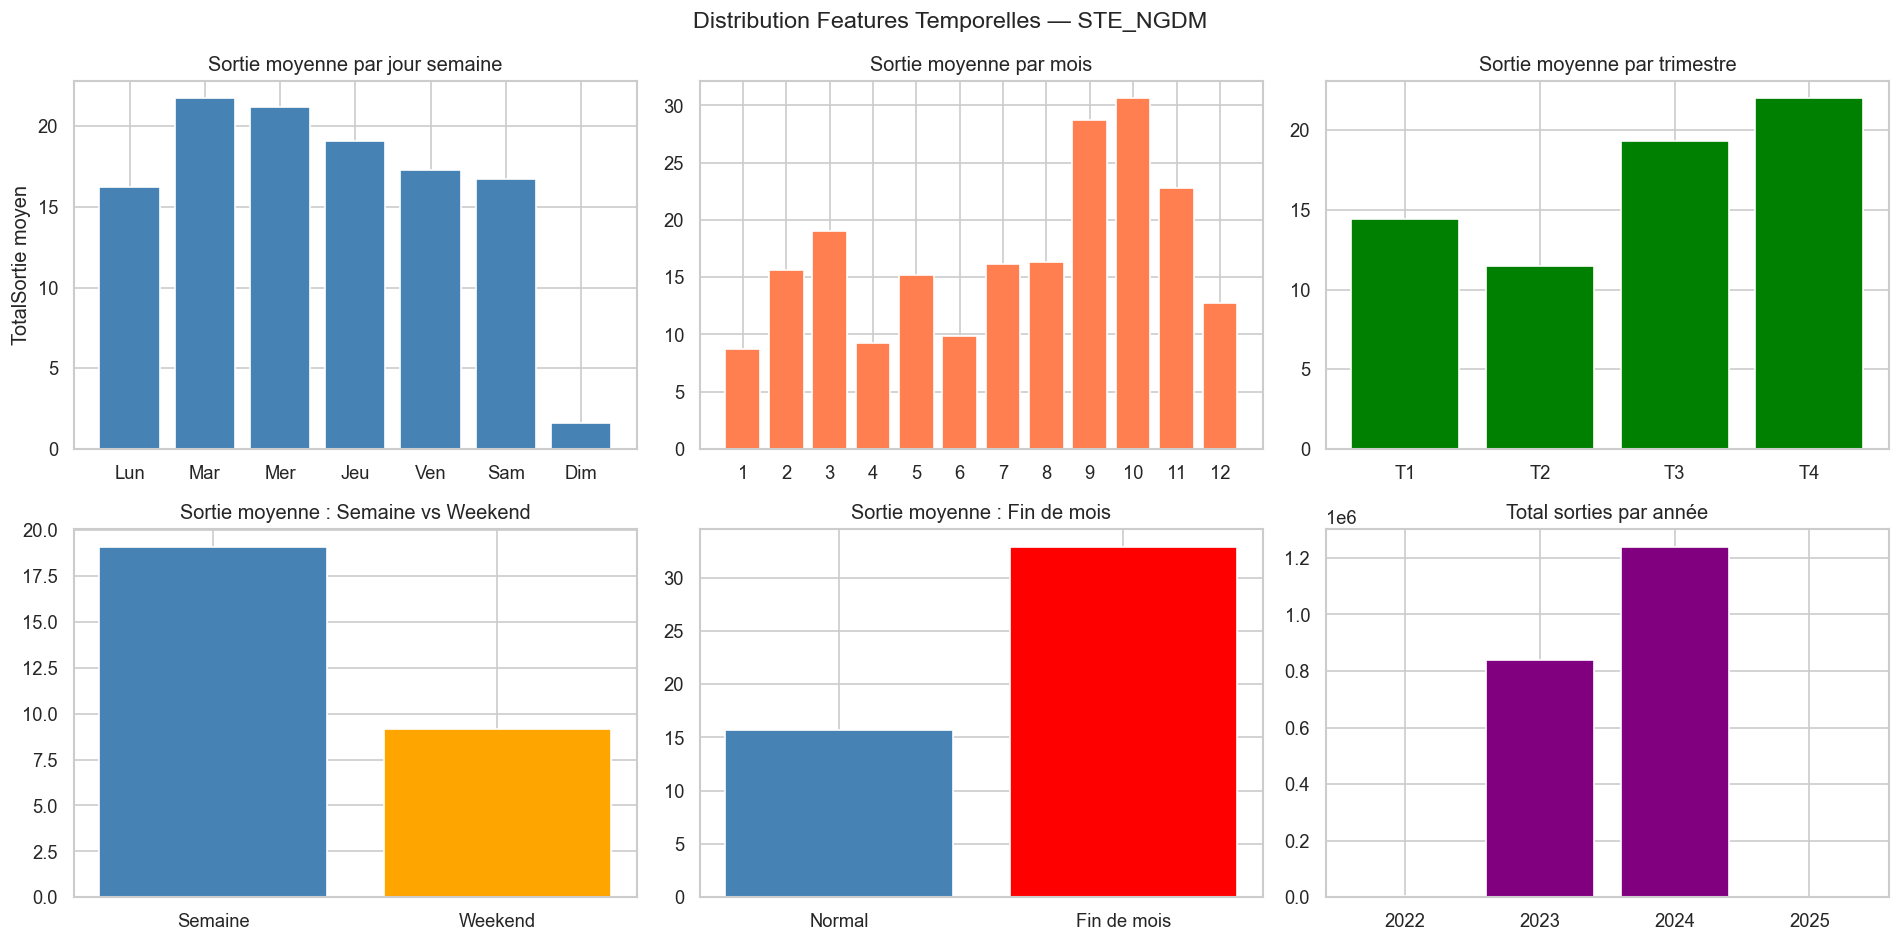

Graphe sauvegardé : features_temporelles.png


In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f'Distribution Features Temporelles — {BASE_NAME}', fontsize=14)

# ── Sorties par jour de semaine ───────────────────────────────
jours_labels = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
by_jour = df_total.groupby('jour_semaine')['TotalSortie'].mean()
axes[0,0].bar(jours_labels, by_jour.values, color='steelblue')
axes[0,0].set_title('Sortie moyenne par jour semaine')
axes[0,0].set_ylabel('TotalSortie moyen')

# ── Sorties par mois ──────────────────────────────────────────
by_mois = df_total.groupby('mois')['TotalSortie'].mean()
axes[0,1].bar(range(1,13), by_mois.values, color='coral')
axes[0,1].set_title('Sortie moyenne par mois')
axes[0,1].set_xticks(range(1,13))

# ── Sorties par trimestre ─────────────────────────────────────
by_trim = df_total.groupby('trimestre')['TotalSortie'].mean()
axes[0,2].bar([f'T{i}' for i in range(1,5)], by_trim.values, color='green')
axes[0,2].set_title('Sortie moyenne par trimestre')

# ── Weekend vs Semaine ────────────────────────────────────────
by_weekend = df_total.groupby('is_weekend')['TotalSortie'].mean()
axes[1,0].bar(['Semaine', 'Weekend'], by_weekend.values, color=['steelblue','orange'])
axes[1,0].set_title('Sortie moyenne : Semaine vs Weekend')

# ── Fin de mois vs normal ─────────────────────────────────────
by_finmois = df_total.groupby('is_fin_mois')['TotalSortie'].mean()
axes[1,1].bar(['Normal', 'Fin de mois'], by_finmois.values, color=['steelblue','red'])
axes[1,1].set_title('Sortie moyenne : Fin de mois')

# ── Évolution annuelle ────────────────────────────────────────
by_annee = df_total.groupby('annee')['TotalSortie'].sum()
axes[1,2].bar(by_annee.index.astype(str), by_annee.values, color='purple')
axes[1,2].set_title('Total sorties par année')

plt.tight_layout()
plt.savefig(f"{EXPLORE_DIR}features_temporelles.png", dpi=120, bbox_inches='tight')
plt.show()
print("Graphe sauvegardé : features_temporelles.png")

In [31]:
# Cellule 10 — Features lag (Random Forest)

In [34]:
# ── Lags calculés par article ─────────────────────────────────
# shift(n) = valeur d'il y a n jours
# rolling  = moyenne glissante des n derniers jours

df_total = df_total.sort_values(['AR_Ref', 'DateJour'])

grp = df_total.groupby('AR_Ref')['TotalSortie']

df_total['sortie_lag_1']    = grp.shift(1)
df_total['sortie_lag_7']    = grp.shift(7)
df_total['sortie_lag_30']   = grp.shift(30)
df_total['rolling_mean_7']  = grp.transform(
    lambda x: x.shift(1).rolling(7,  min_periods=1).mean()
)
df_total['rolling_mean_30'] = grp.transform(
    lambda x: x.shift(1).rolling(30, min_periods=1).mean()
)

lag_cols = ['sortie_lag_1','sortie_lag_7','sortie_lag_30',
            'rolling_mean_7','rolling_mean_30']

print("Features lag créées")
for col in lag_cols:
    nan_pct = df_total[col].isnull().sum() / len(df_total) * 100
    print(f"   {col:20s} → NaN : {nan_pct:.1f}%")

Features lag créées
   sortie_lag_1         → NaN : 0.1%
   sortie_lag_7         → NaN : 0.7%
   sortie_lag_30        → NaN : 3.1%
   rolling_mean_7       → NaN : 0.1%
   rolling_mean_30      → NaN : 0.1%


In [35]:
# Cellule 10b — Graphe features lag

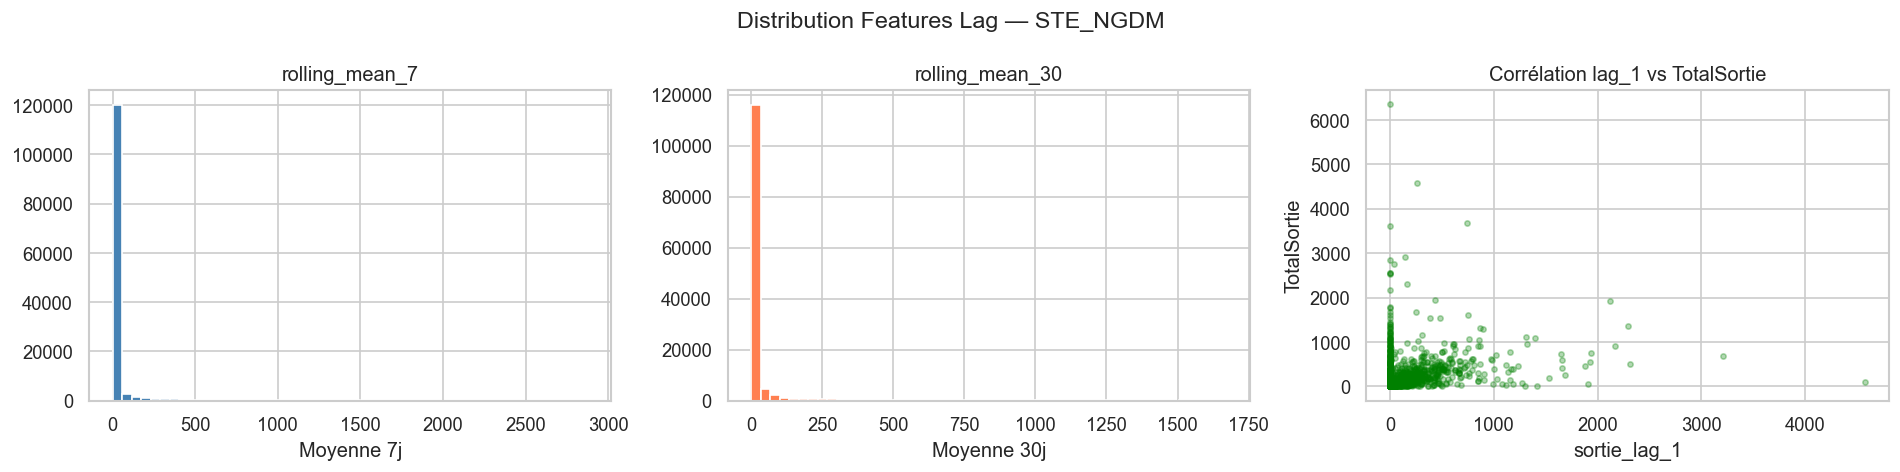

✅ Graphe sauvegardé : features_lag.png


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Distribution Features Lag — {BASE_NAME}', fontsize=14)

# ── Distribution rolling_mean_7 ───────────────────────────────
axes[0].hist(
    df_total['rolling_mean_7'].dropna(),
    bins=50, color='steelblue', edgecolor='white'
)
axes[0].set_title('rolling_mean_7')
axes[0].set_xlabel('Moyenne 7j')

# ── Distribution rolling_mean_30 ─────────────────────────────
axes[1].hist(
    df_total['rolling_mean_30'].dropna(),
    bins=50, color='coral', edgecolor='white'
)
axes[1].set_title('rolling_mean_30')
axes[1].set_xlabel('Moyenne 30j')

# ── Corrélation lag_1 vs TotalSortie ─────────────────────────
sample = df_total[df_total['TotalSortie'] > 0].sample(
    min(2000, len(df_total)), random_state=42
)
axes[2].scatter(
    sample['sortie_lag_1'],
    sample['TotalSortie'],
    alpha=0.3, s=10, color='green'
)
axes[2].set_title('Corrélation lag_1 vs TotalSortie')
axes[2].set_xlabel('sortie_lag_1')
axes[2].set_ylabel('TotalSortie')

plt.tight_layout()
plt.savefig(f"{EXPLORE_DIR}features_lag.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Graphe sauvegardé : features_lag.png")

In [32]:
# Cellule 11 — Target Random Forest

In [40]:
# ── jours_avant_rupture ───────────────────────────────────────
# = combien de jours avant rupture si même rythme de sortie
# = StockFinal / moyenne_sortie_7j
# = NaN si moyenne = 0 (article sans sortie récente)

df_total['jours_avant_rupture'] = np.where(
    df_total['rolling_mean_7'] > 0,
    (df_total['StockFinal'] / df_total['rolling_mean_7']).round(1),
    np.nan
)

# ── Statistiques sur la target ────────────────────────────────
target_valide = df_total['jours_avant_rupture'].dropna()
print("- Target Random Forest créée")
print(f"   Lignes avec target valide : {len(target_valide):,}")
print(f"   Lignes sans target (NaN)  : {df_total['jours_avant_rupture'].isnull().sum():,}")
print(f"   Moyenne jours avant rupture : {target_valide.mean():.1f}j")
print(f"   Min : {target_valide.min():.1f}j  |  Max : {target_valide.max():.1f}j")

- Target Random Forest créée
   Lignes avec target valide : 28,952
   Lignes sans target (NaN)  : 99,220
   Moyenne jours avant rupture : 309.2j
   Min : -3487.8j  |  Max : 226427.8j


In [37]:
# Cellule 11b — Graphe target jours_avant_rupture

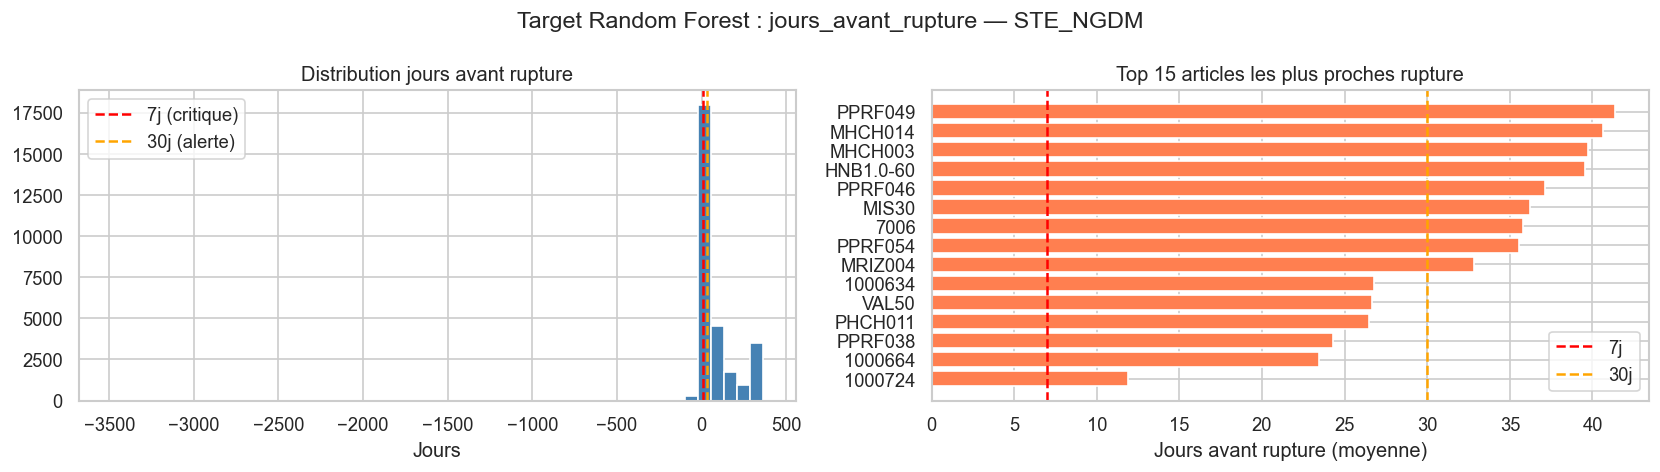

Graphe sauvegardé : target_rupture.png


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'Target Random Forest : jours_avant_rupture — {BASE_NAME}', fontsize=14)

target_valide = df_total['jours_avant_rupture'].dropna()
target_clip   = target_valide.clip(upper=365)  # limiter à 1 an pour la lisibilité

# ── Distribution ──────────────────────────────────────────────
axes[0].hist(target_clip, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(x=7,  color='red',    linestyle='--', label='7j (critique)')
axes[0].axvline(x=30, color='orange', linestyle='--', label='30j (alerte)')
axes[0].set_title('Distribution jours avant rupture')
axes[0].set_xlabel('Jours')
axes[0].legend()

# ── Top articles les plus en danger ──────────────────────────
top_danger = df_total[df_total['jours_avant_rupture'] > 0] \
    .groupby('AR_Ref')['jours_avant_rupture'].mean() \
    .nsmallest(15) \
    .sort_values()

axes[1].barh(top_danger.index, top_danger.values, color='coral')
axes[1].axvline(x=7,  color='red',    linestyle='--', label='7j')
axes[1].axvline(x=30, color='orange', linestyle='--', label='30j')
axes[1].set_title('Top 15 articles les plus proches rupture')
axes[1].set_xlabel('Jours avant rupture (moyenne)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{EXPLORE_DIR}target_rupture.png", dpi=120, bbox_inches='tight')
plt.show()
print("Graphe sauvegardé : target_rupture.png")

In [33]:
# Cellule 12 — Dataset K-Means mensuel + normalisation

In [44]:
# ── Pivot AR_Ref × mois ───────────────────────────────────────
# Les colonnes mois sont créées automatiquement depuis les données
# → s'adapte à n'importe quelle période

df_total['mois_label'] = df_total['DateJour'].dt.to_period('M').astype(str)

df_kmeans = df_total.pivot_table(
    index   = 'AR_Ref',
    columns = 'mois_label',
    values  = 'TotalSortie',
    aggfunc = 'sum',
    fill_value = 0
)

# ── Normalisation pour K-Means ────────────────────────────────
scaler = StandardScaler()
df_kmeans_scaled = pd.DataFrame(
    scaler.fit_transform(df_kmeans),
    index   = df_kmeans.index,
    columns = df_kmeans.columns
)

print("- Dataset K-Means construit")
print(f"   Articles : {df_kmeans.shape[0]}")
print(f"   Mois     : {df_kmeans.shape[1]}")
print(f"   Période  : {df_kmeans.columns[0]} → {df_kmeans.columns[-1]}")
print(f"\n- Normalisation StandardScaler appliquée")

- Dataset K-Means construit
   Articles : 132
   Mois     : 33
   Période  : 2022-12 → 2025-08

- Normalisation StandardScaler appliquée


In [38]:
# Cellule 12b — Graphe K-Means (heatmap mensuelle)

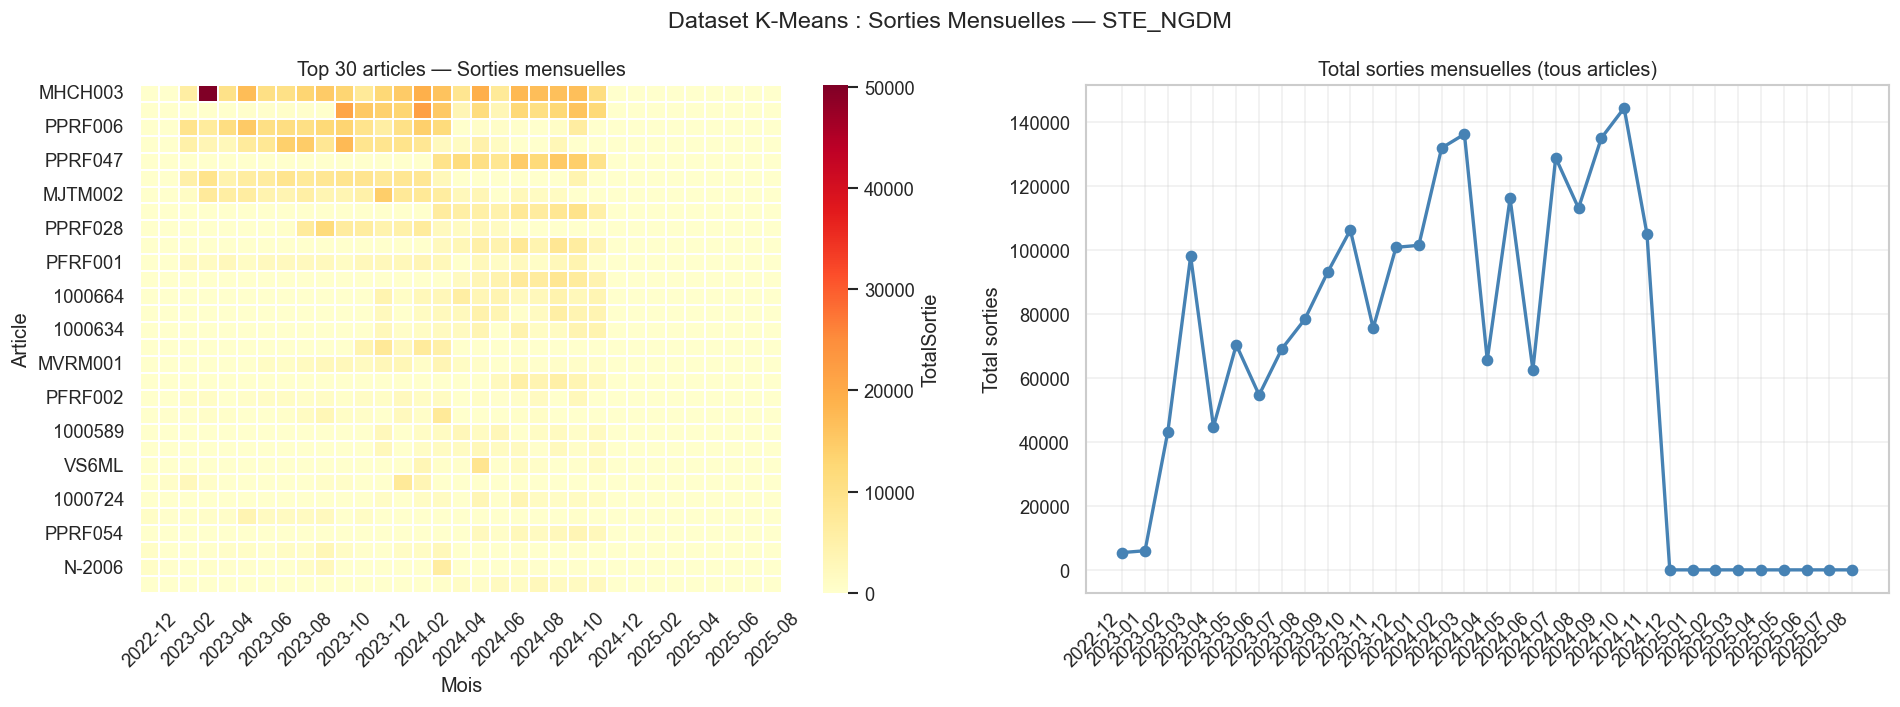

- Graphe sauvegardé : kmeans_mensuel.png


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Dataset K-Means : Sorties Mensuelles — {BASE_NAME}', fontsize=14)

# ── Heatmap top 30 articles ───────────────────────────────────
top_articles = df_kmeans.sum(axis=1).nlargest(30).index
sns.heatmap(
    df_kmeans.loc[top_articles],
    ax=axes[0],
    cmap='YlOrRd',
    linewidths=0.1,
    cbar_kws={'label': 'TotalSortie'}
)
axes[0].set_title('Top 30 articles — Sorties mensuelles')
axes[0].set_xlabel('Mois')
axes[0].set_ylabel('Article')
axes[0].tick_params(axis='x', rotation=45)

# ── Évolution totale mensuelle ────────────────────────────────
total_mensuel = df_kmeans.sum(axis=0)
axes[1].plot(
    range(len(total_mensuel)),
    total_mensuel.values,
    marker='o', color='steelblue', linewidth=2
)
axes[1].set_xticks(range(len(total_mensuel)))
axes[1].set_xticklabels(total_mensuel.index, rotation=45, ha='right')
axes[1].set_title('Total sorties mensuelles (tous articles)')
axes[1].set_ylabel('Total sorties')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{EXPLORE_DIR}kmeans_mensuel.png", dpi=120, bbox_inches='tight')
plt.show()
print("- Graphe sauvegardé : kmeans_mensuel.png")

In [ ]:
# Cellule 13 — Construire les 4 datasets

In [48]:
# ── df_prophet ────────────────────────────────────────────────
# Format Prophet : ds (date), y (valeur à prédire)
df_prophet = df_total[[
    'DateJour', 'AR_Ref', 'AR_Design',
    'FA_CodeFamille', 'FA_Intitule',
    'TotalSortie', 'StockFinal',
    'jour_semaine', 'mois', 'trimestre',
    'annee', 'is_weekend', 'is_fin_mois', 'is_debut_mois'
]].rename(columns={
    'DateJour'   : 'ds',
    'TotalSortie': 'y'
}).copy()

# ── df_rf (Random Forest) ─────────────────────────────────────
df_rf = df_total.dropna(subset=['sortie_lag_1', 'rolling_mean_7']).copy()

# ── df_iforest (Isolation Forest) ────────────────────────────
# Tous les mouvements avec features numériques
df_iforest = df_total[[
    'DateJour', 'AR_Ref',
    'TotalSortie', 'TotalEntree',
    'ValeurSortie', 'ValeurEntree',
    'StockFinal',
    'jour_semaine', 'mois', 'trimestre'
]].copy()

print("4 datasets construits")
print(f"   df_prophet  : {len(df_prophet):,} lignes | {df_prophet['AR_Ref'].nunique()} articles")
print(f"   df_rf       : {len(df_rf):,} lignes       | {df_rf['AR_Ref'].nunique()} articles")
print(f"   df_iforest  : {len(df_iforest):,} lignes  | {df_iforest['AR_Ref'].nunique()} articles")
print(f"   df_kmeans   : {df_kmeans.shape[0]} articles × {df_kmeans.shape[1]} mois")

4 datasets construits
   df_prophet  : 128,172 lignes | 132 articles
   df_rf       : 128,040 lignes       | 132 articles
   df_iforest  : 128,172 lignes  | 132 articles
   df_kmeans   : 132 articles × 33 mois


In [49]:
df_prophet.head()

,ds,AR_Ref,AR_Design,FA_CodeFamille,FA_Intitule,y,StockFinal,jour_semaine,mois,trimestre,annee,is_weekend,is_fin_mois,is_debut_mois
2,2022-12-31,10000721,WAFERS Based Tiffany Breaksta 24*12 MAXI 26gr,TIFFANY,TIFFANY,0.0,0.0,5,12,4,2022,1,1,0
278,2023-01-01,10000721,WAFERS Based Tiffany Breaksta 24*12 MAXI 26gr,TIFFANY,TIFFANY,0.0,0.0,6,1,1,2023,1,0,1
554,2023-01-02,10000721,WAFERS Based Tiffany Breaksta 24*12 MAXI 26gr,TIFFANY,TIFFANY,0.0,0.0,0,1,1,2023,0,0,0
830,2023-01-03,10000721,WAFERS Based Tiffany Breaksta 24*12 MAXI 26gr,TIFFANY,TIFFANY,0.0,0.0,1,1,1,2023,0,0,0
1106,2023-01-04,10000721,WAFERS Based Tiffany Breaksta 24*12 MAXI 26gr,TIFFANY,TIFFANY,0.0,0.0,2,1,1,2023,0,0,0


In [50]:
df_rf.head()

,DateJour,AR_Ref,AR_Design,FA_CodeFamille,FA_Intitule,TotalSortie,TotalEntree,ValeurSortie,ValeurEntree,StockFinal,...,is_weekend,is_fin_mois,is_debut_mois,sortie_lag_1,sortie_lag_7,sortie_lag_30,rolling_mean_7,rolling_mean_30,jours_avant_rupture,mois_label
278,2023-01-01,10000721,WAFERS Based Tiffany Breaksta 24*12 MAXI 26gr,TIFFANY,TIFFANY,0.0,0.0,0.0,0.0,0.0,...,1,0,1,0.0,NaN,NaN,0.0,0.0,NaN,2023-01
554,2023-01-02,10000721,WAFERS Based Tiffany Breaksta 24*12 MAXI 26gr,TIFFANY,TIFFANY,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0.0,NaN,NaN,0.0,0.0,NaN,2023-01
830,2023-01-03,10000721,WAFERS Based Tiffany Breaksta 24*12 MAXI 26gr,TIFFANY,TIFFANY,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0.0,NaN,NaN,0.0,0.0,NaN,2023-01
1106,2023-01-04,10000721,WAFERS Based Tiffany Breaksta 24*12 MAXI 26gr,TIFFANY,TIFFANY,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0.0,NaN,NaN,0.0,0.0,NaN,2023-01
1382,2023-01-05,10000721,WAFERS Based Tiffany Breaksta 24*12 MAXI 26gr,TIFFANY,TIFFANY,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0.0,NaN,NaN,0.0,0.0,NaN,2023-01


In [51]:
df_iforest.head()

,DateJour,AR_Ref,TotalSortie,TotalEntree,ValeurSortie,ValeurEntree,StockFinal,jour_semaine,mois,trimestre
2,2022-12-31,10000721,0.0,0.0,0.0,0.0,0.0,5,12,4
278,2023-01-01,10000721,0.0,0.0,0.0,0.0,0.0,6,1,1
554,2023-01-02,10000721,0.0,0.0,0.0,0.0,0.0,0,1,1
830,2023-01-03,10000721,0.0,0.0,0.0,0.0,0.0,1,1,1
1106,2023-01-04,10000721,0.0,0.0,0.0,0.0,0.0,2,1,1


In [52]:
df_kmeans.head()

mois_label,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,...,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08
AR_Ref,,,,,,,,,,,,,,,,,,,,,
10000721,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2037.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1000589,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1679.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1000591,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1598.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1000634,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3927.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1000664,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3573.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
# Cellule 14 — Vérification qualité

In [54]:
print("=" * 60)
print("  VÉRIFICATION QUALITÉ")
print("=" * 60)

# ── Trous dans le calendrier ──────────────────────────────────
dates_presentes = df_total['DateJour'].unique()
dates_attendues = pd.date_range(
    df_total['DateJour'].min(),
    df_total['DateJour'].max()
)
trous = len(dates_attendues) - len(dates_presentes)
print(f"\n📅 Calendrier")
print(f"   Trous restants : {trous} jours manquants")

# ── NaN critiques ─────────────────────────────────────────────
print(f"\n📊 NaN critiques")
print(f"   StockFinal          : {df_total['StockFinal'].isnull().sum()}")
print(f"   TotalSortie         : {df_total['TotalSortie'].isnull().sum()}")
print(f"   jours_avant_rupture : {df_total['jours_avant_rupture'].isnull().sum()} (normal si sortie=0)")

# ── Distribution TotalSortie ──────────────────────────────────
print(f"\n📈 Distribution TotalSortie")
print(f"   Jours avec sortie > 0  : {(df_total['TotalSortie'] > 0).sum():,}")
print(f"   Jours avec sortie = 0  : {(df_total['TotalSortie'] == 0).sum():,}")
print(f"   Max sortie journalière : {df_total['TotalSortie'].max():.0f}")
print(f"   Moyenne (jours > 0)    : {df_total[df_total['TotalSortie']>0]['TotalSortie'].mean():.1f}")

  VÉRIFICATION QUALITÉ

📅 Calendrier
   Trous restants : 0 jours manquants

📊 NaN critiques
   StockFinal          : 0
   TotalSortie         : 0
   jours_avant_rupture : 99220 (normal si sortie=0)

📈 Distribution TotalSortie
   Jours avec sortie > 0  : 12,327
   Jours avec sortie = 0  : 115,845
   Max sortie journalière : 12071
   Moyenne (jours > 0)    : 169.1


In [55]:
# Cellule 15 — Sauvegarde CSV

In [56]:
df_prophet.to_csv(     f"{OUTPUT_DIR}df_prophet.csv",       index=False)
df_rf.to_csv(          f"{OUTPUT_DIR}df_rf.csv",            index=False)
df_iforest.to_csv(     f"{OUTPUT_DIR}df_iforest.csv",       index=False)
df_kmeans.to_csv(      f"{OUTPUT_DIR}df_kmeans.csv")
df_kmeans_scaled.to_csv(f"{OUTPUT_DIR}df_kmeans_scaled.csv")

print("- Fichiers sauvegardés")
print(f"   📁 {OUTPUT_DIR}")
print(f"   df_prophet.csv")
print(f"   df_rf.csv")
print(f"   df_iforest.csv")
print(f"   df_kmeans.csv")
print(f"   df_kmeans_scaled.csv")

- Fichiers sauvegardés
   📁 ../../output/STE_NGDM/data_clean/
   df_prophet.csv
   df_rf.csv
   df_iforest.csv
   df_kmeans.csv
   df_kmeans_scaled.csv


In [ ]:
# Cellule 16 — Résumé final

In [57]:
print("=" * 60)
print(f"  RÉSUMÉ PREPROCESSING — {BASE_NAME}")
print("=" * 60)
print(f"""
📅 Période originale     : {date_debut_originale} → {date_fin_originale}
📅 Période après clean   : {df_total['DateJour'].min().date()} → {df_total['DateJour'].max().date()}

📦 Articles
   Initiaux             : {nb_articles_initial}
   Retenus (≥{MIN_JOURS_SORTIE}j sortie) : {df_total['AR_Ref'].nunique()}
   Exclus               : {nb_articles_initial - df_total['AR_Ref'].nunique()}

📊 Datasets créés
   df_prophet           : {len(df_prophet):,} lignes
   df_rf                : {len(df_rf):,} lignes
   df_iforest           : {len(df_iforest):,} lignes
   df_kmeans            : {df_kmeans.shape[0]} articles × {df_kmeans.shape[1]} mois

📁 Sauvegardés dans     : {OUTPUT_DIR}
""")

conn.close()
print("Connexion SQL fermée")

  RÉSUMÉ PREPROCESSING — STE_NGDM

📅 Période originale     : 2022-12-31 → 2025-10-01
📅 Période après clean   : 2022-12-31 → 2025-08-27

📦 Articles
   Initiaux             : 278
   Retenus (≥30j sortie) : 132
   Exclus               : 146

📊 Datasets créés
   df_prophet           : 128,172 lignes
   df_rf                : 128,040 lignes
   df_iforest           : 128,172 lignes
   df_kmeans            : 132 articles × 33 mois

📁 Sauvegardés dans     : ../../output/STE_NGDM/data_clean/

Connexion SQL fermée
